**AIML Regression Model Assignment**

---
Name : Sachin Bhabad

PRN : 202301040282

Batch: A3



In [ ]:
# Loan Prediction Dataset Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("REGRESSION MODEL IMPLEMENTATION AND EVALUATION")
print("Dataset: Loan Prediction")
print("="*80)

Mounted at /content/drive
REGRESSION MODEL IMPLEMENTATION AND EVALUATION
Dataset: Loan Prediction



STEP 1: DATASET LOADING AND EXPLORATION

Dataset Shape: (598, 13)

First few rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB
None

Basic Statistics:
       Dependents  ApplicantIncome  CoapplicantIncome  LoanAmount  \
coun

,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


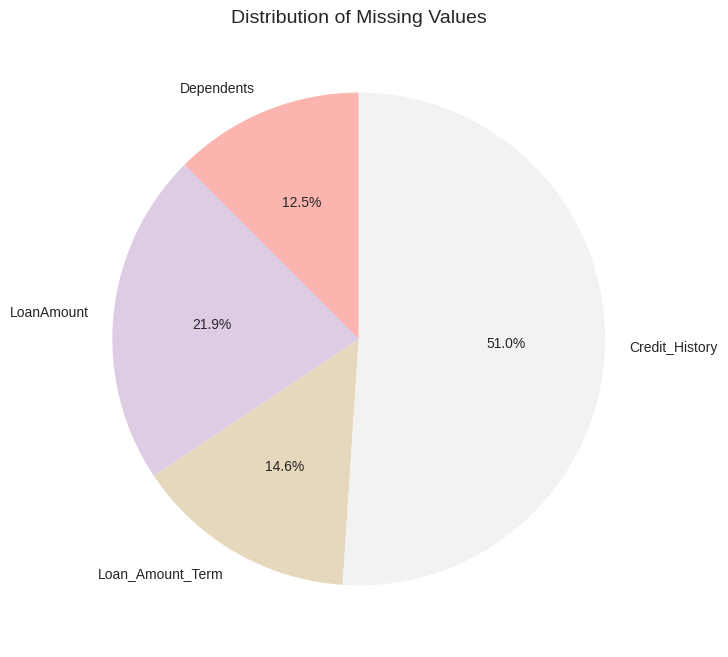

In [ ]:
# STEP 1: LOAD AND EXPLORE DATASET
# ============================================================================

print("\n" + "="*80)
print("STEP 1: DATASET LOADING AND EXPLORATION")
print("="*80)


#dataset from drive
file_path = '/content/drive/My Drive/Datasets/LoanApprovalPrediction.csv'
df = pd.read_csv(file_path)

print("\nDataset Shape:", df.shape)
print("\nFirst few rows:")
display(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing Values:")
missing_values = df.isnull().sum()
display(missing_values)

# Add a pie chart to show missing values
plt.figure(figsize=(8, 8))
missing_values[missing_values > 0].plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title('Distribution of Missing Values', fontsize=14)
plt.ylabel('') # Remove default 'None' ylabel
plt.show()



## STEP 2: IDENTIFYING DEPENDENT AND INDEPENDENT VARIABLES

PROBLEM FORMULATION:
-------------------
For regression analysis, we need a continuous target variable.
In this dataset, 'LoanAmount' is the most suitable continuous variable.

DEPENDENT VARIABLE (Target): LoanAmount
- This is what we want to predict
- It's a continuous numerical variable

INDEPENDENT VARIABLES (Features):
- ApplicantIncome: Primary income source
- CoapplicantIncome: Additional income (if any)
- Loan_Amount_Term: Duration of the loan
- Credit_History: Past credit behavior (0 or 1)
- Plus encoded categorical variables: Gender, Married, Dependents, Education, etc.

REASONING:
LoanAmount depends on the applicant's financial capacity (income),
creditworthiness (credit history), and loan terms.


DATA PREPROCESSING

Handling Missing Values...
Missing Values Before:
 Loan_ID               0
Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

Missing Values After:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Detecting and Handling Outliers using IQR method...


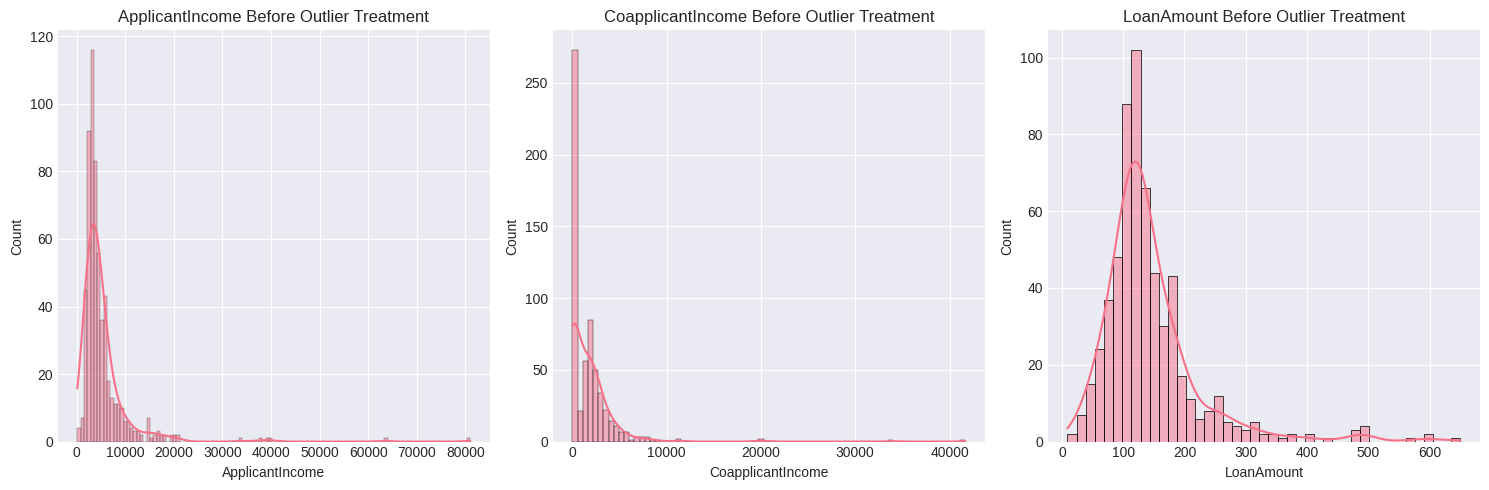

ApplicantIncome: 48 outliers capped.
CoapplicantIncome: 18 outliers capped.
LoanAmount: 43 outliers capped.


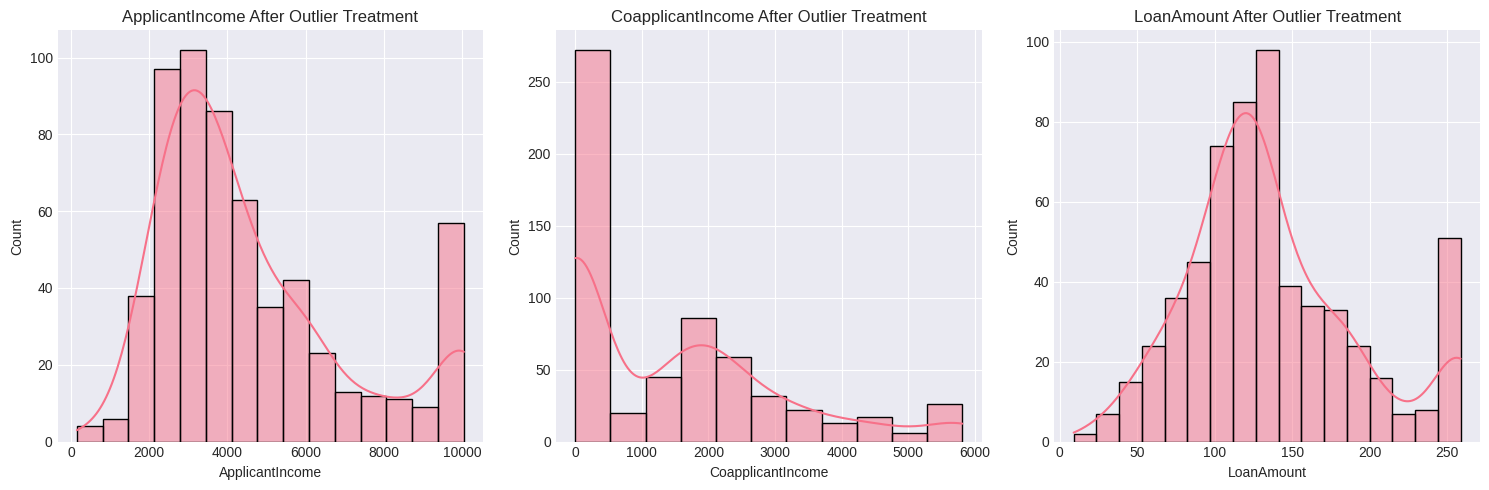


Applying Feature Transformations...


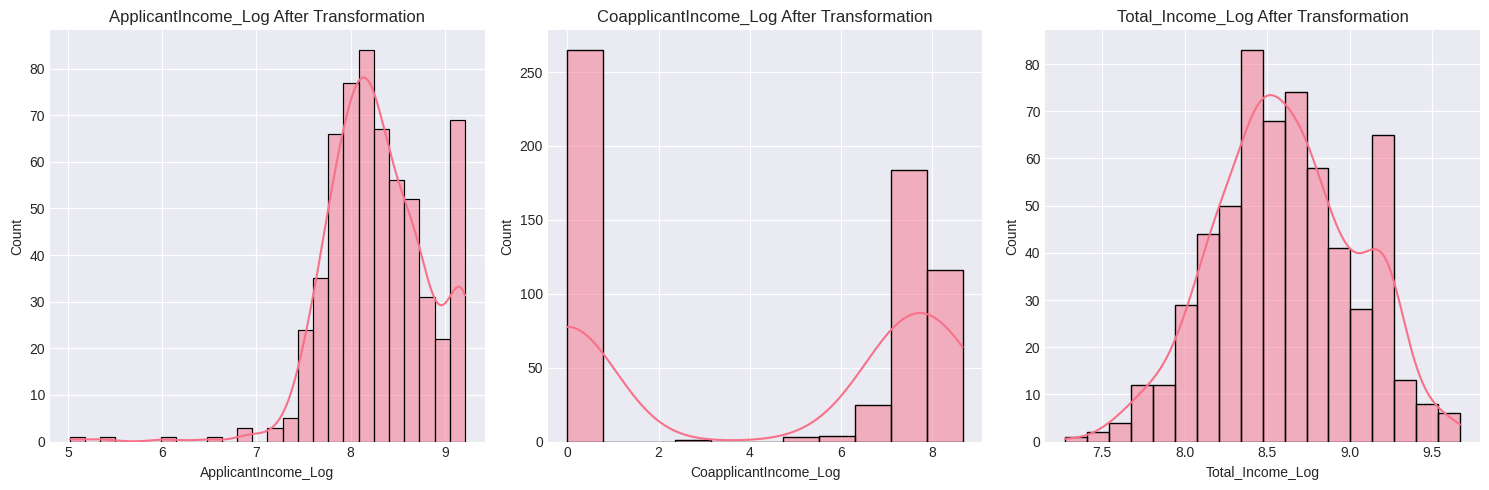


Encoding Categorical Variables...

Encoded Sample Data:
   Gender  Married  Education  Self_Employed  Property_Area
0       1        0          0              0              2
1       1        1          0              0              0
2       1        1          0              1              2
3       1        1          1              0              2
4       1        0          0              0              2


In [ ]:
# ============================================================================
# DATA PREPROCESSING
# ============================================================================
print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

# Create a copy for processing
df_processed = df.copy()

# -------------------------------
# 1. HANDLE MISSING VALUES
# -------------------------------
print("\nHandling Missing Values...")

# Check initial missing count
print("Missing Values Before:\n", df_processed.isnull().sum())

# Strategy:
# - Numerical columns → impute with median
# - Categorical columns → impute with mode (most frequent value)

num_cols = df_processed.select_dtypes(include=[np.number]).columns
cat_cols = df_processed.select_dtypes(include=['object']).columns

# Imputation
for col in num_cols:
    median_val = df_processed[col].median()
    df_processed[col].fillna(median_val, inplace=True)

for col in cat_cols:
    mode_val = df_processed[col].mode()[0]
    df_processed[col].fillna(mode_val, inplace=True)

print("\nMissing Values After:\n", df_processed.isnull().sum())

# -------------------------------
# 2. OUTLIER HANDLING (IQR METHOD)
# -------------------------------
print("\nDetecting and Handling Outliers using IQR method...")

# Visualize distributions before outlier treatment
outlier_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
plt.figure(figsize=(15, 5))
for i, col in enumerate(outlier_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df_processed[col], kde=True)
    plt.title(f'{col} Before Outlier Treatment')
plt.tight_layout()
plt.show()

def treat_outliers_iqr(df, column):
    """
    Cap outliers using IQR method.
    Anything beyond 1.5 * IQR from Q1 and Q3 is capped.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

# Apply to continuous numerical columns likely to have outliers
for col in outlier_cols:
    before_outliers = ((df_processed[col] < df_processed[col].quantile(0.25) - 1.5*(df_processed[col].quantile(0.75)-df_processed[col].quantile(0.25))) |
                       (df_processed[col] > df_processed[col].quantile(0.75) + 1.5*(df_processed[col].quantile(0.75)-df_processed[col].quantile(0.25)))).sum()
    df_processed = treat_outliers_iqr(df_processed, col)
    print(f"{col}: {before_outliers} outliers capped.")

# Visualize distributions after outlier treatment
plt.figure(figsize=(15, 5))
for i, col in enumerate(outlier_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df_processed[col], kde=True)
    plt.title(f'{col} After Outlier Treatment')
plt.tight_layout()
plt.show()


# -------------------------------
# 3. FEATURE TRANSFORMATION
# -------------------------------
print("\nApplying Feature Transformations...")

# Log-transform skewed income variables (reduce skewness)
df_processed['ApplicantIncome_Log'] = np.log1p(df_processed['ApplicantIncome'])
df_processed['CoapplicantIncome_Log'] = np.log1p(df_processed['CoapplicantIncome'])
df_processed['Total_Income'] = df_processed['ApplicantIncome'] + df_processed['CoapplicantIncome']
df_processed['Total_Income_Log'] = np.log1p(df_processed['Total_Income'])

# Visualize distributions after transformation
transformed_cols = ['ApplicantIncome_Log', 'CoapplicantIncome_Log', 'Total_Income_Log']
plt.figure(figsize=(15, 5))
for i, col in enumerate(transformed_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df_processed[col], kde=True)
    plt.title(f'{col} After Transformation')
plt.tight_layout()
plt.show()


# -------------------------------
# 4. FEATURE ENCODING
# -------------------------------
print("\nEncoding Categorical Variables...")

# Binary encoding for Yes/No
binary_map = {'Yes': 1, 'No': 0}
df_processed['Married'] = df_processed['Married'].map(binary_map)
df_processed['Self_Employed'] = df_processed['Self_Employed'].map(binary_map)
df_processed['Loan_Status'] = df_processed['Loan_Status'].map({'Y': 1, 'N': 0})

# Label encoding for non-binary categorical features
le = LabelEncoder()
for col in ['Gender', 'Education', 'Property_Area']:
    df_processed[col] = le.fit_transform(df_processed[col])

print("\nEncoded Sample Data:")
print(df_processed[['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']].head())

MATHEMATICAL FOUNDATION:
-----------------------
Simple Linear Regression: y = β₀ + β₁x + ε

Where:
- y: Dependent variable (LoanAmount)
- x: Independent variable (ApplicantIncome)
- β₀: Intercept
- β₁: Slope
- ε: Error term

LEAST SQUARES METHOD:
The goal is to minimize the Sum of Squared Errors (SSE):
SSE = Σ(yᵢ - ŷᵢ)²

Closed-form solutions:
β₁ = Σ[(xᵢ - x̄)(yᵢ - ȳ)] / Σ(xᵢ - x̄)²
β₀ = ȳ - β₁x̄

Where x̄ and ȳ are means of x and y respectively.

In [ ]:
# ============================================================================
# STEP 3: SIMPLE LINEAR REGRESSION FROM SCRATCH (LEAST SQUARES METHOD)
# ============================================================================
print("\n" + "="*80)
print("STEP 3: SIMPLE LINEAR REGRESSION FROM SCRATCH (LEAST SQUARES)")
print("="*80)

class SimpleLinearRegressionScratch:
    """
    Simple Linear Regression implemented from scratch using Least Squares Method.

    Mathematical approach:
    - Calculate covariance between X and Y
    - Calculate variance of X
    - Slope (β₁) = Cov(X,Y) / Var(X)
    - Intercept (β₀) = mean(Y) - β₁ * mean(X)
    """

    def __init__(self):
        self.beta_0 = None  # Intercept
        self.beta_1 = None  # Slope

    def fit(self, X, y):
        """
        Fit the model using Least Squares Method.

        Parameters:
        X: Independent variable (1D array)
        y: Dependent variable (1D array)
        """
        # Convert to numpy arrays
        X = np.array(X).flatten()
        y = np.array(y).flatten()

        # Calculate means
        X_mean = np.mean(X)
        y_mean = np.mean(y)

        # Calculate slope (beta_1)
        numerator = np.sum((X - X_mean) * (y - y_mean))
        denominator = np.sum((X - X_mean) ** 2)

        self.beta_1 = numerator / denominator

        # Calculate intercept (beta_0)
        self.beta_0 = y_mean - self.beta_1 * X_mean

        print(f"\nModel Parameters (From Scratch):")
        print(f"β₀ (Intercept): {self.beta_0:.4f}")
        print(f"β₁ (Slope): {self.beta_1:.4f}")

        return self

    def predict(self, X):
        """
        Make predictions using the fitted model.

        Formula: y = β₀ + β₁X
        """
        X = np.array(X).flatten()
        return self.beta_0 + self.beta_1 * X

    def score(self, X, y):
        """Calculate R² score"""
        y_pred = self.predict(X)
        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_residual = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_residual / ss_total)
        return r2

# Prepare data for simple linear regression
# Using ApplicantIncome to predict LoanAmount
X_simple = df_processed['ApplicantIncome'].values
y = df_processed['LoanAmount'].values

# Split the data
X_train_simple, X_test_simple, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {len(X_train_simple)}")
print(f"Testing set size: {len(X_test_simple)}")

# Fit the model from scratch
model_scratch = SimpleLinearRegressionScratch()
model_scratch.fit(X_train_simple, y_train)

# Make predictions
y_pred_scratch = model_scratch.predict(X_test_simple)

# Calculate metrics
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
mae_scratch = mean_absolute_error(y_test, y_pred_scratch)
r2_scratch = model_scratch.score(X_test_simple, y_test)

print(f"\nPerformance Metrics (From Scratch):")
print(f"MSE (Mean Squared Error): {mse_scratch:.4f}")
print(f"MAE (Mean Absolute Error): {mae_scratch:.4f}")
print(f"R² Score: {r2_scratch:.4f}")


STEP 3: SIMPLE LINEAR REGRESSION FROM SCRATCH (LEAST SQUARES)

Training set size: 478
Testing set size: 120

Model Parameters (From Scratch):
β₀ (Intercept): 77.1483
β₁ (Slope): 0.0129

Performance Metrics (From Scratch):
MSE (Mean Squared Error): 1775.9493
MAE (Mean Absolute Error): 32.3539
R² Score: 0.3290


In [ ]:
# ============================================================================
# STEP 4: SIMPLE LINEAR REGRESSION USING SKLEARN
# ============================================================================
print("\n" + "="*80)
print("STEP 4: SIMPLE LINEAR REGRESSION USING SKLEARN")
print("="*80)

# Reshape for sklearn (needs 2D array)
X_train_simple_2d = X_train_simple.reshape(-1, 1)
X_test_simple_2d = X_test_simple.reshape(-1, 1)

# Fit sklearn model
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_simple_2d, y_train)

print(f"\nModel Parameters (Using Sklearn):")
print(f"β₀ (Intercept): {model_sklearn.intercept_:.4f}")
print(f"β₁ (Coefficient): {model_sklearn.coef_[0]:.4f}")

# Make predictions
y_pred_sklearn = model_sklearn.predict(X_test_simple_2d)

# Calculate metrics
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
mae_sklearn = mean_absolute_error(y_test, y_pred_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)

print(f"\nPerformance Metrics (Using Sklearn):")
print(f"MSE: {mse_sklearn:.4f}")
print(f"MAE: {mae_sklearn:.4f}")
print(f"R² Score: {r2_sklearn:.4f}")


STEP 4: SIMPLE LINEAR REGRESSION USING SKLEARN

Model Parameters (Using Sklearn):
β₀ (Intercept): 77.1483
β₁ (Coefficient): 0.0129

Performance Metrics (Using Sklearn):
MSE: 1775.9493
MAE: 32.3539
R² Score: 0.3290



STEP 5: COMPARISON - FROM SCRATCH vs SKLEARN

         Metric From Scratch   Sklearn Difference
           MSE    1775.9493 1775.9493   0.000000
           MAE      32.3539   32.3539   0.000000
            R²       0.3290    0.3290   0.000000
β₀ (Intercept)      77.1483   77.1483   0.000000
    β₁ (Slope)       0.0129    0.0129   0.000000

INTERPRETATION:
--------------
The results from both methods should be virtually identical (differences due to 
numerical precision). This validates our from-scratch implementation.

KEY INSIGHTS:
1. Both methods use the same mathematical foundation (Least Squares)
2. Sklearn provides optimized implementations with numerical stability
3. Understanding the math helps in debugging and model interpretation


Visualization saved as 'simple_regression_comparison.png'


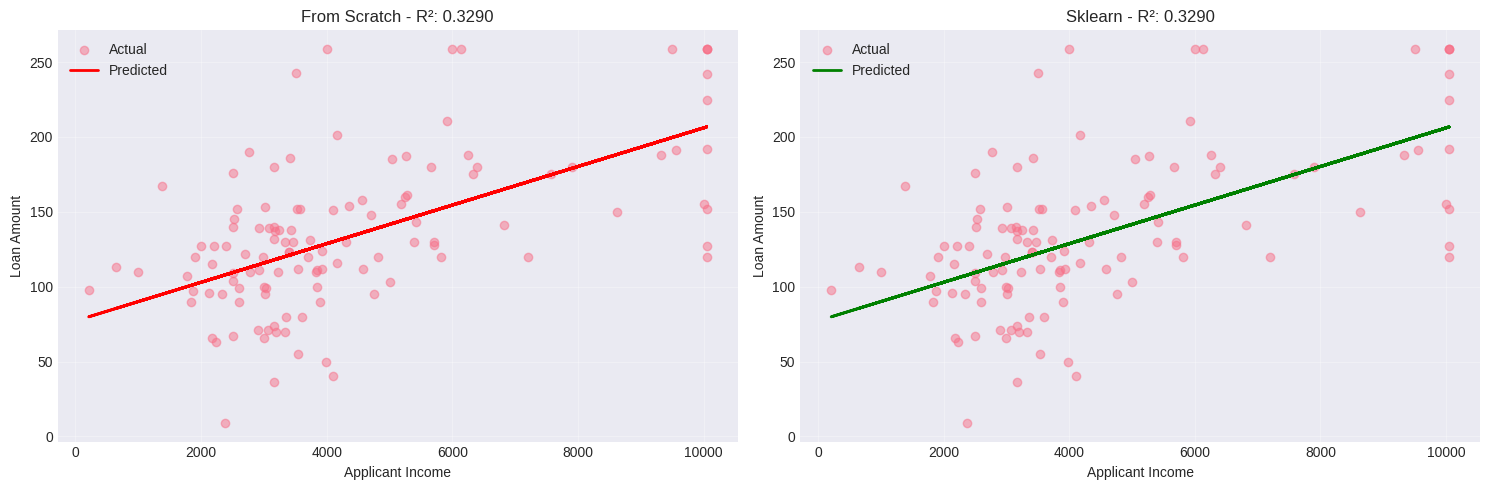

In [ ]:
# ============================================================================
# STEP 5: COMPARISON OF BOTH METHODS
# ============================================================================
print("\n" + "="*80)
print("STEP 5: COMPARISON - FROM SCRATCH vs SKLEARN")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'R²', 'β₀ (Intercept)', 'β₁ (Slope)'],
    'From Scratch': [
        f"{mse_scratch:.4f}",
        f"{mae_scratch:.4f}",
        f"{r2_scratch:.4f}",
        f"{model_scratch.beta_0:.4f}",
        f"{model_scratch.beta_1:.4f}"
    ],
    'Sklearn': [
        f"{mse_sklearn:.4f}",
        f"{mae_sklearn:.4f}",
        f"{r2_sklearn:.4f}",
        f"{model_sklearn.intercept_:.4f}",
        f"{model_sklearn.coef_[0]:.4f}"
    ],
    'Difference': [
        f"{abs(mse_scratch - mse_sklearn):.6f}",
        f"{abs(mae_scratch - mae_sklearn):.6f}",
        f"{abs(r2_scratch - r2_sklearn):.6f}",
        f"{abs(model_scratch.beta_0 - model_sklearn.intercept_):.6f}",
        f"{abs(model_scratch.beta_1 - model_sklearn.coef_[0]):.6f}"
    ]
})

print("\n", comparison_df.to_string(index=False))



# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: From Scratch
axes[0].scatter(X_test_simple, y_test, alpha=0.5, label='Actual')
axes[0].plot(X_test_simple, y_pred_scratch, 'r-', linewidth=2, label='Predicted')
axes[0].set_xlabel('Applicant Income')
axes[0].set_ylabel('Loan Amount')
axes[0].set_title(f'From Scratch - R²: {r2_scratch:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Sklearn
axes[1].scatter(X_test_simple, y_test, alpha=0.5, label='Actual')
axes[1].plot(X_test_simple, y_pred_sklearn, 'g-', linewidth=2, label='Predicted')
axes[1].set_xlabel('Applicant Income')
axes[1].set_ylabel('Loan Amount')
axes[1].set_title(f'Sklearn - R²: {r2_sklearn:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('simple_regression_comparison.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved as 'simple_regression_comparison.png'")

MATHEMATICAL FOUNDATION:
-----------------------
Multiple Linear Regression: y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ + ε

In matrix form: Y = Xβ + ε

GRADIENT DESCENT ALGORITHM:
--------------------------
Goal: Minimize Cost Function J(β) = (1/2m) Σ(hβ(x⁽ⁱ⁾) - y⁽ⁱ⁾)²

Update Rule:
βⱼ := βⱼ - α * (∂J(β)/∂βⱼ)

Where:
- α: Learning rate (step size)
- ∂J(β)/∂βⱼ: Partial derivative of cost function w.r.t. βⱼ

Derivative: ∂J(β)/∂βⱼ = (1/m) Σ(hβ(x⁽ⁱ⁾) - y⁽ⁱ⁾) * xⱼ⁽ⁱ⁾

ALGORITHM STEPS:
1. Initialize parameters β randomly
2. Calculate predictions: ŷ = Xβ
3. Calculate cost: J(β)
4. Calculate gradients: ∂J(β)/∂β
5. Update parameters: β := β - α * gradient
6. Repeat steps 2-5 until convergence


STEP 6: MULTIPLE LINEAR REGRESSION - GRADIENT DESCENT FROM SCRATCH

Feature Matrix Shape: (598, 9)
Target Vector Shape: (598,)

Applying Feature Scaling...
WHY: Gradient Descent converges faster when features are on similar scales

Before scaling - Mean: [4.62356328e+03 1.40310653e+03 3.40343096e+02 8.51464435e-01
 7.21757322e-01 8.11715481e-01 6.35983264e-01 2.23849372e-01
 1.73640167e-01]
After scaling - Mean: [-5.13303951e-17  3.15879354e-17  3.79055225e-16 -1.47023258e-16
  1.56546092e-16 -1.62352698e-16 -2.96833687e-16 -3.03801614e-16
 -1.07538339e-16]
After scaling - Std: [1. 1. 1. 1. 1. 1. 1. 1. 1.]

------------------------------------------------------------
TRAINING MULTIPLE LINEAR REGRESSION WITH GRADIENT DESCENT
------------------------------------------------------------
Iteration 0: Cost = 10926.945868
Iteration 100: Cost = 4532.745308
Iteration 200: Cost = 2190.613663
Iteration 300: Cost = 1323.872759
Iteration 400: Cost = 999.454472
Iteration 499: Cost = 877.027892

Fi

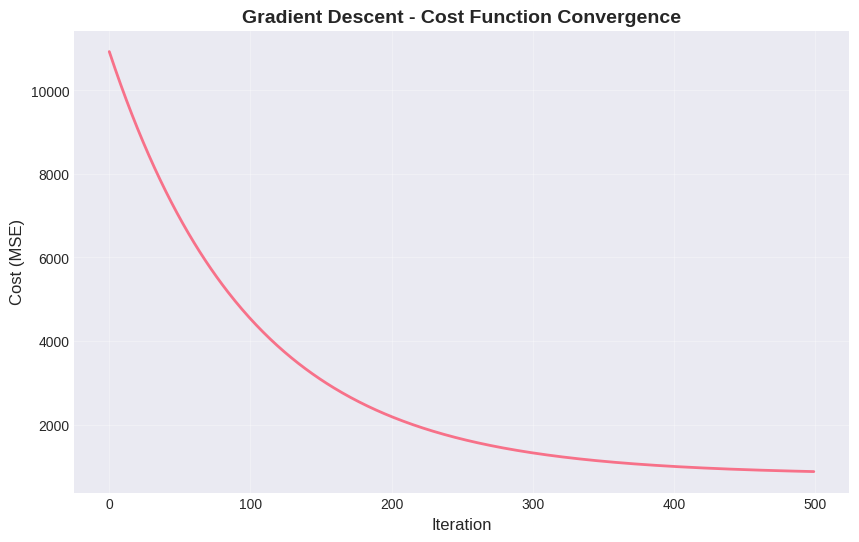

In [ ]:
# ============================================================================
# STEP 6: MULTIPLE LINEAR REGRESSION WITH GRADIENT DESCENT (FROM SCRATCH)
# ============================================================================
print("\n" + "="*80)
print("STEP 6: MULTIPLE LINEAR REGRESSION - GRADIENT DESCENT FROM SCRATCH")
print("="*80)

class MultipleLinearRegressionGD:
    """
    Multiple Linear Regression using Gradient Descent.

    This implementation includes:
    - Feature scaling for faster convergence
    - Cost history tracking
    - Convergence monitoring
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y, verbose=True):
        """
        Fit the model using Gradient Descent.

        Parameters:
        X: Feature matrix (m samples × n features)
        y: Target vector (m samples)
        verbose: Print progress
        """
        # Convert to numpy arrays
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)

        # Get dimensions
        m, n = X.shape

        # Initialize parameters
        self.weights = np.zeros((n, 1))
        self.bias = 0

        # Gradient Descent
        prev_cost = float('inf')

        for i in range(self.n_iterations):
            # Forward pass: Calculate predictions
            y_pred = np.dot(X, self.weights) + self.bias

            # Calculate cost (Mean Squared Error)
            cost = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
            self.cost_history.append(cost)

            # Calculate gradients
            dw = (1 / m) * np.dot(X.T, (y_pred - y))
            db = (1 / m) * np.sum(y_pred - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Check convergence
            if abs(prev_cost - cost) < self.tolerance:
                if verbose:
                    print(f"\nConverged at iteration {i}")
                break

            prev_cost = cost

            # Print progress
            if verbose and (i % 100 == 0 or i == self.n_iterations - 1):
                print(f"Iteration {i}: Cost = {cost:.6f}")

        print(f"\nFinal Parameters:")
        print(f"Bias (β₀): {self.bias:.4f}")
        print(f"Weights (β₁...βₙ): {self.weights.flatten()}")

        return self

    def predict(self, X):
        """Make predictions"""
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias

    def score(self, X, y):
        """Calculate R² score"""
        y = np.array(y).reshape(-1, 1)
        y_pred = self.predict(X)
        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_residual = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_residual / ss_total)
        return r2

# Prepare data for multiple linear regression
feature_columns = [
    'ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term',
    'Credit_History', 'Dependents', 'Gender',
    'Married', 'Education', 'Self_Employed'
]

X_multiple = df_processed[feature_columns].values
y_multiple = df_processed['LoanAmount'].values

print(f"\nFeature Matrix Shape: {X_multiple.shape}")
print(f"Target Vector Shape: {y_multiple.shape}")

# Split the data
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

# Feature Scaling (IMPORTANT for Gradient Descent)
print("\nApplying Feature Scaling...")
print("WHY: Gradient Descent converges faster when features are on similar scales")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_mult)
X_test_scaled = scaler.transform(X_test_mult)

print(f"\nBefore scaling - Mean: {X_train_mult.mean(axis=0)}")
print(f"After scaling - Mean: {X_train_scaled.mean(axis=0)}")
print(f"After scaling - Std: {X_train_scaled.std(axis=0)}")

# Fit the model with Gradient Descent
print("\n" + "-"*60)
print("TRAINING MULTIPLE LINEAR REGRESSION WITH GRADIENT DESCENT")
print("-"*60)

model_gd = MultipleLinearRegressionGD(
    learning_rate=0.005,
    n_iterations=500,
    tolerance=1e-5
)

model_gd.fit(X_train_scaled, y_train_mult, verbose=True)

# Make predictions
y_pred_gd = model_gd.predict(X_test_scaled)

# Calculate metrics
mse_gd = mean_squared_error(y_test_mult, y_pred_gd)
mae_gd = mean_absolute_error(y_test_mult, y_pred_gd)
r2_gd = model_gd.score(X_test_scaled, y_test_mult)

print(f"\nPerformance Metrics (Gradient Descent):")
print(f"MSE: {mse_gd:.4f}")
print(f"MAE: {mae_gd:.4f}")
print(f"R² Score: {r2_gd:.4f}")

# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(model_gd.cost_history, linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.title('Gradient Descent - Cost Function Convergence', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('gradient_descent_convergence.png', dpi=300, bbox_inches='tight')
print("\nCost history plot saved as 'gradient_descent_convergence.png'")

In [ ]:
# ============================================================================
# STEP 7: MULTIPLE LINEAR REGRESSION USING SKLEARN
# ============================================================================
print("\n" + "="*80)
print("STEP 7: MULTIPLE LINEAR REGRESSION USING SKLEARN")
print("="*80)

print("""
SKLEARN IMPLEMENTATION:
----------------------
Sklearn's LinearRegression uses the Normal Equation (closed-form solution):
β = (XᵀX)⁻¹Xᵀy

ADVANTAGES:
- No need to choose learning rate
- No iterations required
- Direct solution

DISADVANTAGES:
- Computationally expensive for large datasets (O(n³) complexity)
- Matrix inversion can be numerically unstable
""")

# Fit sklearn model
model_sklearn_mult = LinearRegression()
model_sklearn_mult.fit(X_train_scaled, y_train_mult)

print(f"\nModel Parameters (Using Sklearn):")
print(f"Intercept (β₀): {model_sklearn_mult.intercept_:.4f}")
print(f"Coefficients (β₁...βₙ): {model_sklearn_mult.coef_}")

# Make predictions
y_pred_sklearn_mult = model_sklearn_mult.predict(X_test_scaled)

# Calculate metrics
mse_sklearn_mult = mean_squared_error(y_test_mult, y_pred_sklearn_mult)
mae_sklearn_mult = mean_absolute_error(y_test_mult, y_pred_sklearn_mult)
r2_sklearn_mult = r2_score(y_test_mult, y_pred_sklearn_mult)

print(f"\nPerformance Metrics (Using Sklearn):")
print(f"MSE: {mse_sklearn_mult:.4f}")
print(f"MAE: {mae_sklearn_mult:.4f}")
print(f"R² Score: {r2_sklearn_mult:.4f}")


STEP 7: MULTIPLE LINEAR REGRESSION USING SKLEARN

SKLEARN IMPLEMENTATION:
----------------------
Sklearn's LinearRegression uses the Normal Equation (closed-form solution):
β = (XᵀX)⁻¹Xᵀy

ADVANTAGES:
- No need to choose learning rate
- No iterations required
- Direct solution

DISADVANTAGES:
- Computationally expensive for large datasets (O(n³) complexity)
- Matrix inversion can be numerically unstable


Model Parameters (Using Sklearn):
Intercept (β₀): 136.7552
Coefficients (β₁...βₙ): [35.13891917 22.7011265   5.55372102 -1.75979788  4.08539666 -0.78473701
  3.63714758 -1.73846341 -0.14682715]

Performance Metrics (Using Sklearn):
MSE: 1292.5925
MAE: 26.2944
R² Score: 0.5117



STEP 8: COMPARISON - GRADIENT DESCENT vs SKLEARN (Multiple Regression)

    Metric Gradient Descent   Sklearn Difference
      MSE        1410.9953 1292.5925 118.402824
      MAE          28.3961   26.2944   2.101725
       R²           0.4669    0.5117   0.044732
Intercept         125.5999  136.7552  11.155379

Feature Coefficients Comparison:
          Feature  GD Weights  Sklearn Coef  Absolute Difference
  ApplicantIncome   29.887056     35.138919             5.251863
CoapplicantIncome   18.251118     22.701127             4.450008
 Loan_Amount_Term    4.943341      5.553721             0.610380
   Credit_History   -1.342893     -1.759798             0.416905
       Dependents    3.728997      4.085397             0.356400
           Gender    1.149371     -0.784737             1.934108
          Married    4.395605      3.637148             0.758457
        Education   -4.112366     -1.738463             2.373903
    Self_Employed    1.459016     -0.146827             1.605843

I

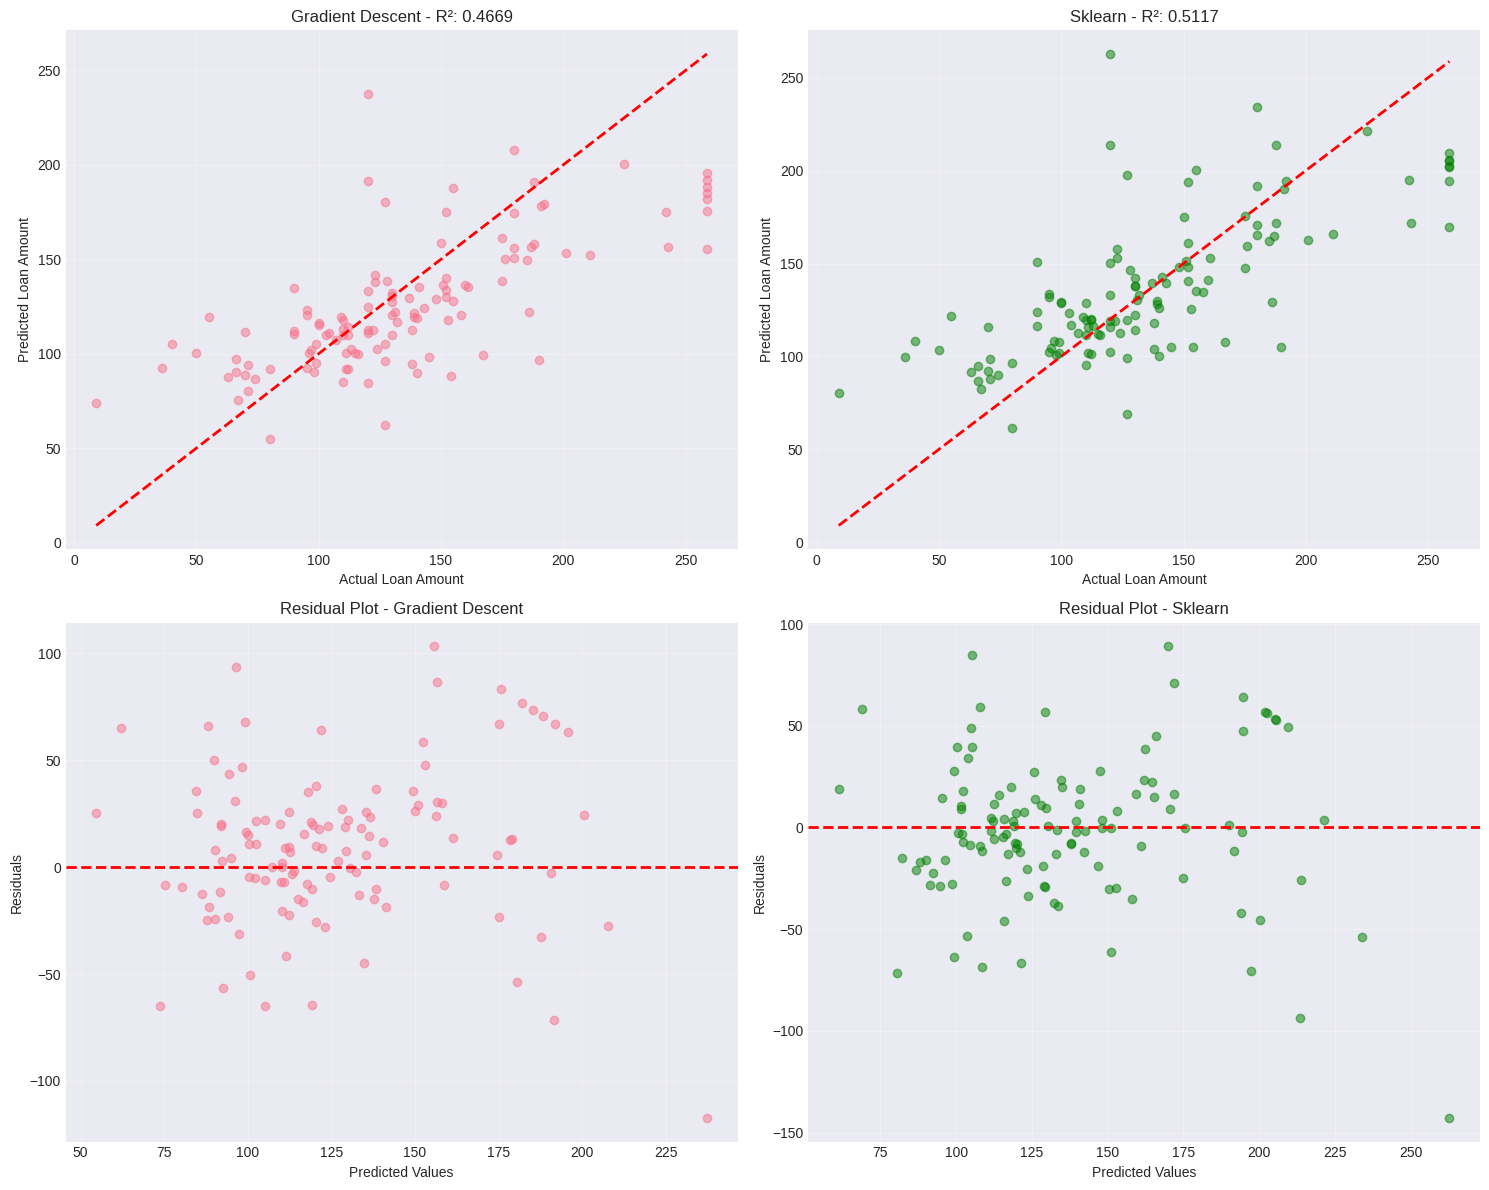

In [ ]:
# ============================================================================
# STEP 8: COMPARISON OF GRADIENT DESCENT VS SKLEARN
# ============================================================================
print("\n" + "="*80)
print("STEP 8: COMPARISON - GRADIENT DESCENT vs SKLEARN (Multiple Regression)")
print("="*80)

comparison_mult_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'R²', 'Intercept'],
    'Gradient Descent': [
        f"{mse_gd:.4f}",
        f"{mae_gd:.4f}",
        f"{r2_gd:.4f}",
        f"{model_gd.bias:.4f}"
    ],
    'Sklearn': [
        f"{mse_sklearn_mult:.4f}",
        f"{mae_sklearn_mult:.4f}",
        f"{r2_sklearn_mult:.4f}",
        f"{model_sklearn_mult.intercept_:.4f}"
    ],
    'Difference': [
        f"{abs(mse_gd - mse_sklearn_mult):.6f}",
        f"{abs(mae_gd - mae_sklearn_mult):.6f}",
        f"{abs(r2_gd - r2_sklearn_mult):.6f}",
        f"{abs(model_gd.bias - model_sklearn_mult.intercept_):.6f}"
    ]
})

print("\n", comparison_mult_df.to_string(index=False))

# Feature importance comparison
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'GD Weights': model_gd.weights.flatten(),
    'Sklearn Coef': model_sklearn_mult.coef_
})
feature_importance_df['Absolute Difference'] = abs(
    feature_importance_df['GD Weights'] - feature_importance_df['Sklearn Coef']
)

print("\nFeature Coefficients Comparison:")
print(feature_importance_df.to_string(index=False))

print("""
INTERPRETATION:
--------------
1. CONVERGENCE: Gradient Descent should converge to similar values as Sklearn
2. DIFFERENCES: Small differences are expected due to:
   - Iterative vs. closed-form solution
   - Numerical precision
   - Stopping criteria

3. WHEN TO USE WHICH:
   Gradient Descent:
   - Large datasets (millions of features)
   - Online learning scenarios
   - When memory is limited

   Normal Equation (Sklearn):
   - Small to medium datasets
   - When you need exact solution
   - When computational resources are available
""")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Predictions comparison - Gradient Descent
axes[0, 0].scatter(y_test_mult, y_pred_gd, alpha=0.5)
axes[0, 0].plot([y_test_mult.min(), y_test_mult.max()],
                [y_test_mult.min(), y_test_mult.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Loan Amount')
axes[0, 0].set_ylabel('Predicted Loan Amount')
axes[0, 0].set_title(f'Gradient Descent - R²: {r2_gd:.4f}')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Predictions comparison - Sklearn
axes[0, 1].scatter(y_test_mult, y_pred_sklearn_mult, alpha=0.5, color='green')
axes[0, 1].plot([y_test_mult.min(), y_test_mult.max()],
                [y_test_mult.min(), y_test_mult.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Loan Amount')
axes[0, 1].set_ylabel('Predicted Loan Amount')
axes[0, 1].set_title(f'Sklearn - R²: {r2_sklearn_mult:.4f}')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals - Gradient Descent
residuals_gd = y_test_mult - y_pred_gd.flatten()
axes[1, 0].scatter(y_pred_gd, residuals_gd, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Values')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot - Gradient Descent')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals - Sklearn
residuals_sklearn = y_test_mult - y_pred_sklearn_mult
axes[1, 1].scatter(y_pred_sklearn_mult, residuals_sklearn, alpha=0.5, color='green')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Values')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residual Plot - Sklearn')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multiple_regression_comparison.png', dpi=300, bbox_inches='tight')
print("\nComparison plots saved as 'multiple_regression_comparison.png'")

print("\n" + "="*80)
print("PART 1 COMPLETE: Steps 1-8 Finished")
print("Continue to next cell for Steps 9-10 (Polynomial, Locally Weighted, Lasso, Ridge)")
print("="*80)

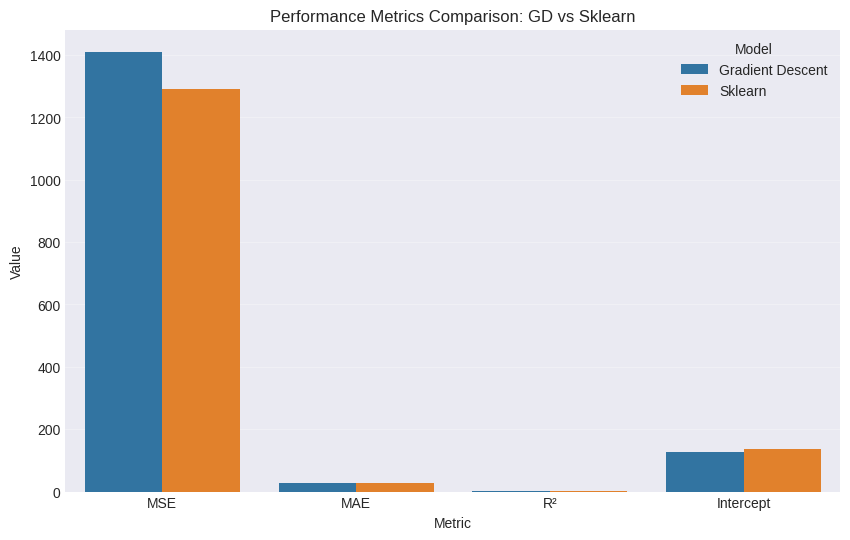

In [ ]:
# Visualization of performance metrics comparison
comparison_melted = comparison_mult_df.melt('Metric', var_name='Model', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', hue='Model', data=comparison_melted, palette='tab10')
plt.title('Performance Metrics Comparison: GD vs Sklearn')
plt.ylabel('Value')
plt.grid(axis='y', alpha=0.3)
plt.show()